<div style="display: flex; justify-content: space-between; align-items: flex-start; border-bottom: 2px solid #555555; padding-bottom: 15px; margin-bottom: 12px;">
    <div style="width: 100%;">
        <h2>
            <span style="color: #B30033;">▍</span>CARDIS
        </h2>
        <h1 style="margin-top: -10px;">
            Equidad y Calibración (Post-Modelado)
        </h1>
    </div>
</div>

**Notebook de Experimentación**

**Proyecto:** Clinical AI Risk Decision Support System (CARDIS)  
**Asignatura:** Desarrollo e Integración de Servicios de IA (DISIA)  
**Grupo 6:** Alonso Crespo · Diego Guerrero · José Lara · Cristina Serrano  
**Fecha:** Marzo 2026  

### Objetivo

Este notebook verifica si el modelo obtenido en pasos anteriores es equitativo y posee un rendimiento similar para cualquier franja de edad, y si las predicciones hechas por el modelo encajan con el riesgo real.

### Research Questions abordadas

- **RQ1:** ¿El modelo posee un rendimiento similar sea cual sea el rango de edad?
- **RQ2:** ¿Las predicciones del modelo se traducen en resultados reales?

## 0. Configuración del entorno

In [13]:
# ── Librerías ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ML — Métricas de evaluación y calibración
from sklearn.metrics import f1_score, recall_score, precision_score, classification_report, brier_score_loss
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.base import BaseEstimator, TransformerMixin

# Librería de equidad
from fairlearn.metrics import MetricFrame, equalized_odds_difference, selection_rate

# Configuración de reproducibilidad
SEED = 42
np.random.seed(SEED)

print("Entorno configurado correctamente.")
print(f"  NumPy       : {np.__version__}")
print(f"  pandas      : {pd.__version__}")
print(f"  scikit-learn: {__import__('sklearn').__version__}")
print(f"  Fairlearn   : {__import__('fairlearn').__version__}")
print(f"  SEED        : {SEED}")

Entorno configurado correctamente.
  NumPy       : 2.2.6
  pandas      : 2.3.3
  scikit-learn: 1.7.2
  Fairlearn   : 0.13.0
  SEED        : 42


## 1. Carga de datos y preparación

En primer lugar, cargaremos los datos originales que almacenamos en hitos anteriores. Por otro lado, los datos procesados provienen del pipeline de preprocesamiento del Hito 2 (`cardis_pipeline.ipynb`), que exportó dos versiones del dataset de entrenamiento:

| Archivo | Contenido | Uso |
|---------|-----------|-----|
| `cardio_risk_train_fe.csv` | Solo Feature Engineering (sin escalar) | Modelos de árboles (RF, LightGBM, XGBoost) |
| `cardio_risk_train_pipeline.csv` | FE + imputación + Target Encoding + RobustScaler | Regresión Logística |

Aunque esto se menciona en el notebook de (`cardis_modelado.ipynb`), la razón de tener dos conjuntos de datos distintos es porque el modelo requiere que los datos estén en escalas similares. Por ello, utilizaremos el segundo dataset.

Por otra parte, se utilizará el modelo obtenido tras entrenar una instancia de LightGBM (`cardis_modelo_final.joblib`), almacenado en la carpeta _models_, y obtenido en el cuaderno mendionado anteriormente.

In [14]:
# ── Target Encoder (replicado de cardis_pipeline.ipynb) ────────────────────────
# Sustituye cada categoría por la media suavizada del target en esa categoría.
# El smoothing evita sobreajuste en categorías con pocas observaciones.
class TargetEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, columns, smoothing=1.0):
        self.columns = columns
        self.smoothing = smoothing
        self.mapping_ = {}
        self.global_mean_ = None

    def fit(self, X, y):
        X = X.copy()
        self.global_mean_ = y.mean()
        for col in self.columns:
            if col in X.columns:
                stats = y.groupby(X[col]).agg(['mean', 'count'])
                # Fórmula de suavizado: pondera entre la media de la categoría
                # y la media global según el nº de observaciones
                smooth = (
                    (stats['count'] * stats['mean'] + self.smoothing * self.global_mean_)
                    / (stats['count'] + self.smoothing)
                )
                self.mapping_[col] = smooth.to_dict()
        return self

    def transform(self, X):
        X = X.copy()
        for col in self.columns:
            if col in X.columns:
                # Categorías no vistas en fit se rellenan con la media global
                X[col] = X[col].map(self.mapping_.get(col, {})).fillna(self.global_mean_)
        return X


try:
    # Carga del dataset original
    df_original = pd.read_csv(Path("../data/raw/cardio_risk_train.csv"))

    # Carga del dataset escalado
    df_escalado = pd.read_csv(Path("../data/processed/cardio_risk_train_pipeline.csv"))
    
    # Carga del modelo entrenado
    model = joblib.load(Path("models/cardis_modelo_final.joblib"))
    
    print("Recursos cargados correctamente:")
    print(f"   Dataset original: {df_original.shape[0]} filas y {df_original.shape[1]} columnas.")
    print(f"   Dataset escalado: {df_escalado.shape[0]} filas y {df_escalado.shape[1]} columnas.")

    if 'modelo' in model:
        pipeline_final = model['modelo']

    print(f"   Modelo : {type(pipeline_final).__name__}")
except FileNotFoundError as e:
    print(f"Error: No se encontró el archivo. {e}")

Recursos cargados correctamente:
   Dataset original: 24000 filas y 21 columnas.
   Dataset escalado: 24000 filas y 39 columnas.
   Modelo : LGBMClassifier


## 2. Generación de predicciones y probabilidades

Antes de empezar a trabajar con el análisis de los sesgos, se deben conocer los resultados del modelo tras hacer inferencia con los datos originales. Para ello, utilizaremos el conjunto de datos escalado, ya que son los apropiados para usar nuestro modelo. Utilizaremos un umbral dinámico sobre los percentiles para que el modelo sea lo más preciso posible.

In [15]:
# 1. Preparación de las características y la columna objetivo
X_val = df_escalado.drop(columns=['riesgo_cv'])
y_true = df_escalado['riesgo_cv']

# 2. Obtener probabilidades del modelo
lgbm_model = model['modelo']
y_proba = lgbm_model.predict_proba(X_val)[:, 1]

# 3. Ajuste de umbral dinámico
umbral_dinamico = np.percentile(y_proba, 78)
y_pred = (y_proba >= umbral_dinamico).astype(int)

# 4. Reporte de resultados
casos_reales = int(y_true.sum())
casos_predichos = int(y_pred.sum())

print(f"   Generación de predicciones completada")
print(f"   Casos positivos REALES    : {casos_reales}")
print(f"   Casos positivos PREDICHOS : {casos_predichos}")
print(f"   Diferencia absoluta       : {abs(casos_reales - casos_predichos)}")
print("-" * 50)
print("   Reporte de rendimiento")
print(classification_report(y_true, y_pred))

   Generación de predicciones completada
   Casos positivos REALES    : 5256
   Casos positivos PREDICHOS : 5280
   Diferencia absoluta       : 24
--------------------------------------------------
   Reporte de rendimiento
              precision    recall  f1-score   support

           0       0.84      0.84      0.84     18744
           1       0.44      0.45      0.45      5256

    accuracy                           0.76     24000
   macro avg       0.64      0.65      0.64     24000
weighted avg       0.76      0.76      0.76     24000



Al trabajar con un umbral dinámico, estamos forzando al modelo a estar igual de equilibrado como en la realidad, donde existen en torno al 22% de casos positivos. De esta forma, operaciones posteriores para analizar la equidad y calibración del modelo se nos son facilitados.

## 3. Partición del conjunto de datos por franja de edad

Con el fin de analizar los posibles sesgos del modelo obtenido para pacientes en diferentes franjas de edad, vamos a particionar el dataset en 5 franjas diferentes:
- 30 a 39 años
- 40 a 49 años
- 50 a 59 años
- 60 a 69 años
- 70 a 84 años

Como podemos observar, la última partición incluye hasta los 84 años, edad máxima presente en nuestro conjunto de datos.

In [16]:
# 1. Definición de cortes
bins = [30, 40, 50, 60, 70, 85]
labels = ['30-39', '40-49', '50-59', '60-69', '70-84']

# 2. Creación del DataFrame de evaluación
df_eval = pd.DataFrame({
    'y_true': y_true,
    'y_pred': y_pred,
    'y_proba': y_proba,
    'edad_real': df_original['edad']
})

# 3. Aplicar el binning
df_eval['franja_edad'] = pd.cut(
    df_eval['edad_real'], 
    bins=bins, 
    labels=labels, 
    right=False
)

# 4. Resumen de la distribución
print("Distribución por décadas:")
resumen_bins = df_eval.groupby('franja_edad', observed=True).agg(
    Total_Pacientes=('y_true', 'count'),
    Casos_Reales=('y_true', 'sum'),
    Porcentaje_Positivos=('y_true', lambda x: (x.mean() * 100).round(2))
)

display(resumen_bins)

Distribución por décadas:


,Total_Pacientes,Casos_Reales,Porcentaje_Positivos
franja_edad,,,
30-39,4353,138,3.17
40-49,4487,284,6.33
50-59,4340,614,14.15
60-69,4308,1173,27.23
70-84,6512,3047,46.79


Como cabría esperar, el porcentaje de casos positivos aumenta en cada franja de edad, indicando una correlación lineal directa.

## 4. Análisis de sesgos

En esta sección, nos enfocaremos en analizar la posible presencia de sesgos en nuestro modelo, obteniendo primero las métricas más relevantes (F1-Score, Recall, Precision) para cada franja de edad, y más tarde una métrica muy relevante en este caso, como son las _Equalized Odds_.

<Figure size 1200x600 with 0 Axes>

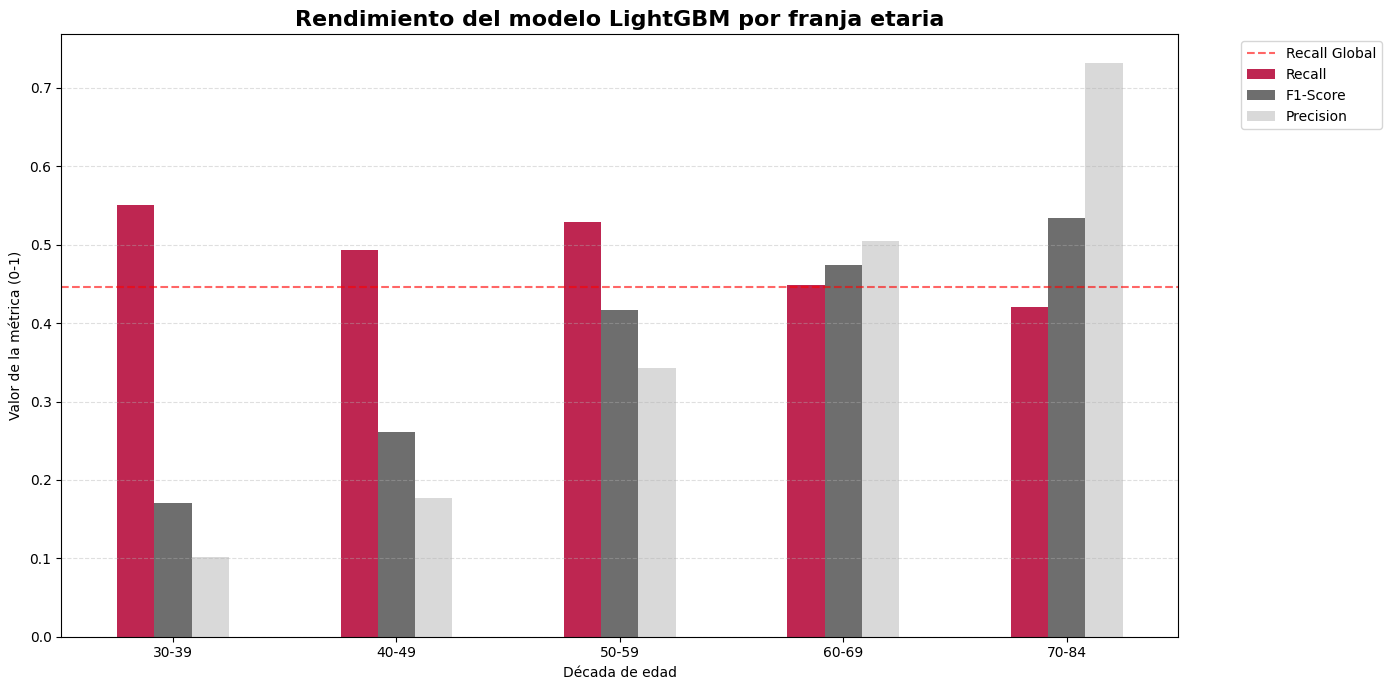

Tabla de resultados por grupo:


,F1-Score,Recall,Precision,Selection Rate
franja_edad,,,,
30-39,0.1710,0.5507,0.1012,0.1725
40-49,0.2607,0.4930,0.1772,0.1761
50-59,0.4164,0.5293,0.3432,0.2182
60-69,0.4747,0.4484,0.5043,0.2421
70-84,0.5338,0.4201,0.7318,0.2686


------------------------------------------------------------
Disparidad detectada (Equalized Odds Difference): 0.1306
------------------------------------------------------------
Nota: Se observa una disparidad significativa (>0.1).
El modelo muestra variaciones en la capacidad de detección según la edad.


In [17]:
# 1. Configuración de Métricas
metrics = {
    'F1-Score': f1_score,
    'Recall': recall_score,
    'Precision': precision_score,
    'Selection Rate': selection_rate
}

# 2. Creación del MetricFrame por década
mf = MetricFrame(
    metrics=metrics,
    y_true=df_eval['y_true'],
    y_pred=df_eval['y_pred'],
    sensitive_features=df_eval['franja_edad']
)

# 3. Cálculo de disparidad (Equalized Odds Difference)
# Mide la diferencia máxima entre grupos tanto en TPR como en FPR.
eo_diff = equalized_odds_difference(
    df_eval['y_true'], 
    df_eval['y_pred'], 
    sensitive_features=df_eval['franja_edad']
)

# 4. Comparativa de Métricas por Década
plt.figure(figsize=(12, 6))
metrics_to_plot = ['Recall', 'F1-Score', 'Precision']
df_plot = mf.by_group[metrics_to_plot]

# Dibujamos un gráfico de barras agrupadas
df_plot.plot(kind='bar', figsize=(14, 7), color=['#B30033', '#555555', '#D3D3D3'], alpha=0.85)

# Añadimos la línea del recall promedio global como referencia clínica
plt.axhline(y=recall_score(df_eval['y_true'], df_eval['y_pred']), 
            color='red', linestyle='--', alpha=0.6, label='Recall Global')

plt.title('Rendimiento del modelo LightGBM por franja etaria', fontsize=16, fontweight='bold')
plt.ylabel('Valor de la métrica (0-1)')
plt.xlabel('Década de edad')
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# 5. Impresión de resultados
print("Tabla de resultados por grupo:")
display(mf.by_group.round(4))

print("-" * 60)
print(f"Disparidad detectada (Equalized Odds Difference): {eo_diff:.4f}")
print("-" * 60)
if eo_diff > 0.1:
    print("Nota: Se observa una disparidad significativa (>0.1).")
    print("El modelo muestra variaciones en la capacidad de detección según la edad.")

Como podemos ver en la gráfica, el recall se mantiene más o menos estable para todos los grupos, siendo mayor para las franjas más jóvenes. Por otro lado, tanto el F1-Score como la precisión van aumentando conforme aumenta la idea, de forma similar a la tasa de selección, aunque de una forma mucho menos notable.

Todo esto puede indicar que el modelo está sesgado favorablemente hacia los grupos de edad avanzada (70-84), lo que sugiere que nuestro sistema podría no ser lo más adecuado para adultos jóvenes. También refueza nuestra teoría de que existe un sesgo desfavorable en aquellos casos donde los niveles de glucosa no se han reportado.

Esto se reafirma con el Equalized Odds Diference, que tiene un valor mayor a 0.1 (aproximadamente 0.1306), lo que indica que las tasas de falsos y verdaderos positivos es muy diferente para cada grupo etario.

## 5. Análisis de calibración

A pesar de que hayamos detectado sesgos anteriormente en el modelo, es igual de importante calibrarlo, para determinar si es realmente fiable a la hora de generar predicciones para los pacientes. Para ello, utilizaremos curvas de calibración y _Brier Score Loss_.

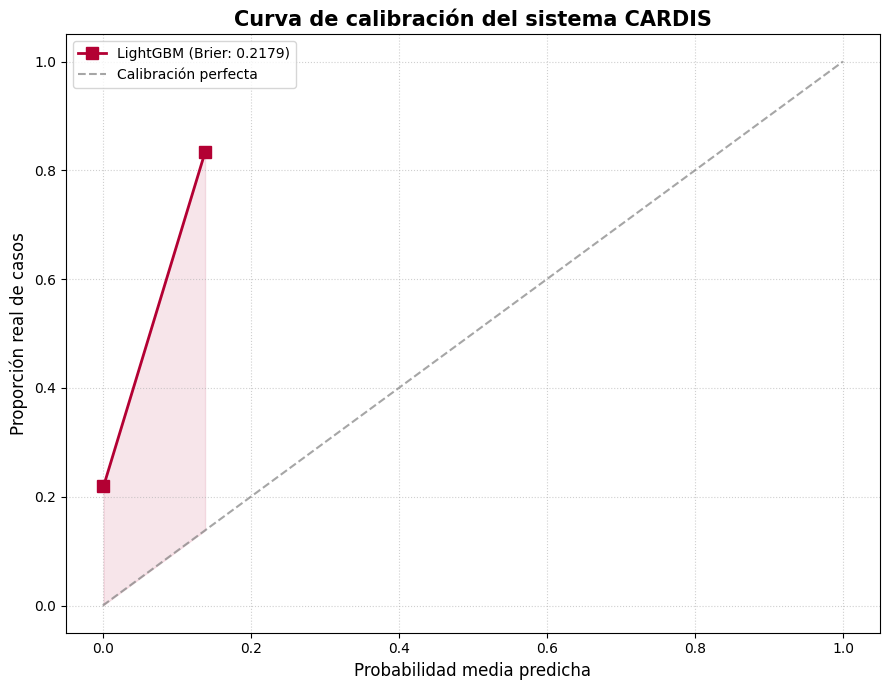

Análisis de calibración finalizado.
   Brier Score: 0.2179


In [18]:
# 1. Cálculo del Brier Score Loss
# Mide la precisión de las probabilidades (0 es perfecto, 1 es error total)
brier_lgbm = brier_score_loss(df_eval['y_true'], df_eval['y_proba'])

# 2. Generación de la curva de calibración
# Comparamos la probabilidad media predicha con la fracción real de positivos
prob_true, prob_pred = calibration_curve(df_eval['y_true'], df_eval['y_proba'], n_bins=10)

# 3. Visualización de la Curva de Calibración
plt.figure(figsize=(9, 7))

# Línea del modelo
plt.plot(prob_pred, prob_true, marker='s', markersize=8, label=f'LightGBM (Brier: {brier_lgbm:.4f})', 
         color='#B30033', linewidth=2)

# Línea de calibración perfecta
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Calibración perfecta', alpha=0.7)

plt.title('Curva de calibración del sistema CARDIS', fontsize=15, fontweight='bold')
plt.xlabel('Probabilidad media predicha', fontsize=12)
plt.ylabel('Proporción real de casos', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)

plt.fill_between(prob_pred, prob_true, prob_pred, color='#B30033', alpha=0.1)

plt.tight_layout()
plt.show()

print(f"Análisis de calibración finalizado.")
print(f"   Brier Score: {brier_lgbm:.4f}")

El análisis de calibración mediante el _Brier Score_ nos ayuda a revelar que el modelo tiene a infraestimar el riesgo real del paciente, pues la curva de calibración se sitúa por encima de la diagonal de referencia, lo que indica que la frecuencia real de eventos cardiovasculares es superior a la asignada por el modelo. Esto implica que el modelo actúa de forma conservadora, asignando probabilidades de riesgo bajas a pacientes con una incidencia mayor.

Aún así, un valor cercano a 0.2 en un dataset desbalanceado no es un mal resultado, pero nos lleva a pensar que las probabilidades y el conjunto de datos de forma general no están perfectamente refinados. Una posible solución para aplacar el problema es el uso de **Isotonic Regression**, ideal para se tienen suficientes datos y un modelo notablemente optimista o pesimista.

/home/diego/Escritorio/.venv/lib/python3.12/site-packages/sklearn/calibration.py:330: FutureWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


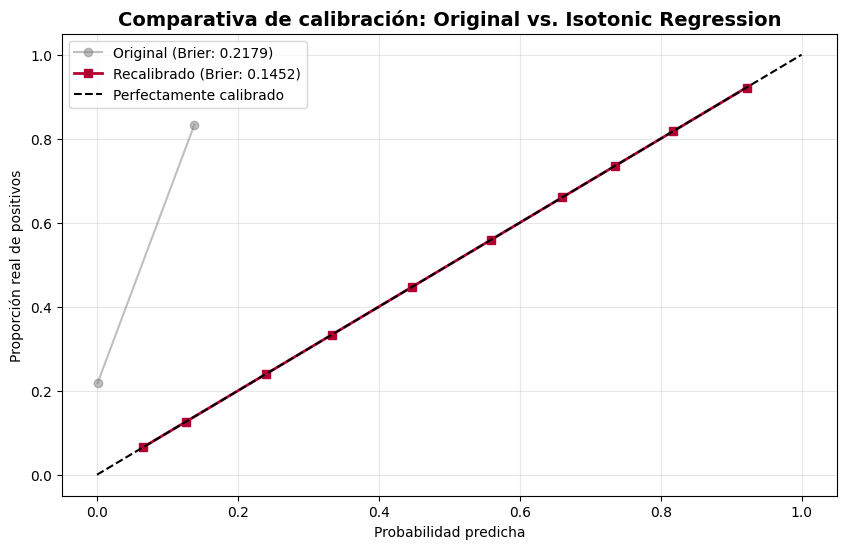

RESULTADO DE RECALIBRACIÓN:
   Brier Score inicial: 0.2179
   Brier Score final  : 0.1452
   Mejora relativa    : 33.36%


In [19]:
# 1. Ajustar el recalibrador con Isotonic Regression
calibrador = CalibratedClassifierCV(lgbm_model, method='isotonic', cv='prefit')
calibrador.fit(X_val, y_true)

# 2. Generar nuevas probabilidades recalibradas
y_proba_calibrated = calibrador.predict_proba(X_val)[:, 1]

# 3. Calcular nuevos Brier Scores
brier_antes = brier_score_loss(y_true, y_proba)
brier_despues = brier_score_loss(y_true, y_proba_calibrated)

# 4. Generar curvas para comparar
prob_true_old, prob_pred_old = calibration_curve(y_true, y_proba, n_bins=10)
prob_true_new, prob_pred_new = calibration_curve(y_true, y_proba_calibrated, n_bins=10)

# 5. Visualización comparativa
plt.figure(figsize=(10, 6))
plt.plot(prob_pred_old, prob_true_old, marker='o', label=f'Original (Brier: {brier_antes:.4f})', color='gray', alpha=0.5)
plt.plot(prob_pred_new, prob_true_new, marker='s', label=f'Recalibrado (Brier: {brier_despues:.4f})', color='#B30033', linewidth=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='black', label='Perfectamente calibrado')

plt.title('Comparativa de calibración: Original vs. Isotonic Regression', fontsize=14, fontweight='bold')
plt.xlabel('Probabilidad predicha')
plt.ylabel('Proporción real de positivos')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"RESULTADO DE RECALIBRACIÓN:")
print(f"   Brier Score inicial: {brier_antes:.4f}")
print(f"   Brier Score final  : {brier_despues:.4f}")
print(f"   Mejora relativa    : {((brier_antes - brier_despues) / brier_antes * 100):.2f}%")

Esta nueva gráfica nos ayuda a ver como el _Brier Score_ ha disminuido de un 0.2179 a un 0.1452, una mejora de más del 33%, lo que convierte a nuestro modelo en una herramienta de predicción de riesgos fiable. En cuanto a las líneas de la gráfica, el sistema recalibrado tiene una línea que se solapa prácticamente con el sistema perfectamente calibrado, lo que nos indica que ahora el porcentaje de predicciones del modelo se corresponde muy fielmente con la realidad, dejando de ser "pesimista".

_Isotonic Regression_ resulta tan útil porque nuestra curva original era casi una línea recta, pero desplazada hacia arriba. Este tipo de regresión es ideal para corregir estos sesgos sistemáticos sin prácticamente consecuencias negativas.

Este proceso nos ayuda a obtener un modelo que, aún presentando una disparidad entre ciertas franjas de edad, tiene una alta fiabilidad y sirve como herramienta de apoyo a personal médico, siempre y cuando tengan en mente que el sistema es más preciso en ancianos.

Por último, podemos obtener el _Equalized Odds Diference_, y comparar el efecto de la recalibración.

In [24]:
y_proba_calibrated = calibrador.predict_proba(X_val)[:, 1]
umbral_calibrado = np.percentile(y_proba_calibrated, 78)
y_pred_calibrated = (y_proba_calibrated >= umbral_calibrado).astype(int)
y_pred_final = y_pred_calibrated

# 1. Cálculo de disparidad (Equalized Odds Difference)
eo_diff_calib = equalized_odds_difference(
    df_eval['y_true'], 
    y_pred_final, 
    sensitive_features=df_eval['franja_edad']
)

# 2. Impresión de resultados finales
print(f"⚖️ Disparidad detectada post-calibración (Equalized Odds Difference): {eo_diff_calib:.4f}")

⚖️ Disparidad detectada post-calibración (Equalized Odds Difference): 0.1282


Como podemos ver, persiste una disparidad significativa, lo que confirma que la calibración mejora la fiabilidad de la probabilidad, pero el sesgo en la detección por edad es un problema estructural de los datos.

## 6. Exportación del modelo final

Se exportan todos los artefactos necesarios para el equipo:

- **`cardis_modelo_final_calibrado.joblib`**: contiene el modelo LightGBM entrenado y calibrado, el umbral recomendado, el _Brier Score_ y los nombres de las características.


In [26]:
save_path = Path("models/cardis_modelo_final_calibrado.joblib")
sistema_final = {
    'modelo_calibrado': calibrador,
    'umbral_recomendado': umbral_calibrado,
    'brier_score': brier_score_loss(y_true, y_proba_calibrated),
    'feature_names': model['feature_names']
}

try:
    joblib.dump(sistema_final, save_path)
    print(f"¡Sistema calibrado almacenado con éxito!")
except Exception as e:
    print(f"Error al guardar el modelo: {e}")

¡Sistema calibrado almacenado con éxito!


## 7. Resumen de resultados

Los archivos generados por este notebook se resumen a continuación:

| Archivo | Contenido |
| :--- | :--- |
| `figures/fig_sesgos.png` | Análisis de sesgos del modelo |
| `figures/fig_calibración.png` | Análisis de calibración del modelo |
| `figures/fig_recalibración.png` | Análisis de calibración del modelo tras recalibración |
| `models/cardis_modelo_final_calibrado.joblib` | CalibratedClassifierCV |

## 8. Conclusiones del experimento

### ¿Qué hemos aprendido?

Los resultados permiten responder a las dos preguntas de investigación planteadas:

**RQ1 - ¿El modelo posee un rendimiento similar sea cual sea el rango de edad?** No, el análisis de equidad revela un sesgo generacional destacado en el sistema CARDIS (con un _Equalized Odds Difference_ de aproximadamente 0.13). Aunque el rendimiento general no es malo, el modelo es notablemente mejor en pacientes con avanzada edad, y al contrario con pacientes jóvenes.

**RQ2 - ¿Las predicciones del modelo se traducen en resultados reales?** Tras la intervención técnica, sí. Inicialmente, el modelo presentaba una calibración deficiente, con un _Brier Score_ de 0.2179, infraestimando el riesgo. Para corregirlo, se aplicó una regresión isotónica que permitió reducirlo a 0.1452, logrando que la curva de calibración sea casi perfecta.

### En resumen

El sistema CARDIS es ahora un modelo **fiable y transparente**, pero con matices de equidad. Se ha logrado un modelo cuyas probabilidades son honestas, pero que arrastra sesgos de los datos originales con respecto a la edad. Finalmente, tenemos un sistema que no solo predice, sino que permite al personal médico tomar decisiones basadas en probabilidades reales, siendo conscientes de los sesgos conocidos.

## Declaración de uso de inteligencia artificial

Los autores del presente trabajo declaran que todas las decisiones de diseño experimental, la selección de modelos y métricas, la interpretación de los resultados y las conclusiones han sido tomadas de forma íntegra por los miembros del equipo, apoyándose en los conocimientos adquiridos en la asignatura y en la literatura de referencia.

La inteligencia artificial (Claude, Anthropic) ha sido empleada como herramienta de apoyo en las siguientes tareas instrumentales:

- **Asistencia en código:** generación de estructuras base de notebooks, funciones de evaluación y visualización, que posteriormente fueron revisadas, adaptadas y validadas por los autores.
- **Redacción y estilo:** revisión ortográfica y estilística del texto, así como sugerencias de estructura para las celdas de markdown explicativas.
- **Apoyo en la resolución de problemas técnicos:** apoyo para los resultados obtenidos a lo largo del desarollo de este cuaderno.
- **Contraste de interpretaciones:** en algunos resultados cuya lectura no era inmediata (como la interpretación de los gráficos de curvas de calibración), la IA se utilizó como interlocutor para contrastar hipótesis, cuya validez fue siempre verificada por los autores.

En ningún caso la inteligencia artificial ha sustituido el criterio técnico o académico del equipo. Los autores asumen plena responsabilidad sobre el contenido, los análisis y las conclusiones de este trabajo.